In [151]:
from dlfs.base import Module, Loss, Optimizer, Layer

from dlfs.modules import SequentialWrapper
from dlfs.layers import DenseLayer, ConvLayer, ConvTransposeLayer, MaxPoolLayer
from dlfs.activation import ReLU, Sigmoid, GELU, LeakyReLU, TanH

from dlfs.loss import MSE_Loss, BCE_Loss
from dlfs.optimizers import Optimizer_Adam, Optimizer_AdamW
from dlfs.helpers import im2col, col2im, im2col_strided, col2im_strided, get_random_batch, load_mnist, select_mnist_labels, preprocess_whole_mnist

import numpy as np
import matplotlib.pyplot as plt

In [152]:
class TinyUNet(Module):
    def __init__(self, image_channels=1, t_emb_dim=128):
        # --- Encoder ---
        self.conv1 = ConvLayer(image_channels, 32, kernel_size=3, stride=1, padding=1)
        self.relu1 = ReLU()
        self.down1 = MaxPoolLayer(pool_size=2, stride=2)

        self.conv2 = ConvLayer(32, 64, kernel_size=3, stride=1, padding=1)
        self.relu2 = ReLU()
        self.down2 = MaxPoolLayer(pool_size=2, stride=2)

        # --- Bottleneck ---
        self.bot_conv = ConvLayer(64, 64, kernel_size=3, stride=1, padding=1)
        self.bot_relu = ReLU()

        # --- Decoder ---
        self.up1 = ConvTransposeLayer(64, 32, kernel_size=2, stride=2)
        self.relu3 = ReLU()

        self.up2 = ConvTransposeLayer(32, 32, kernel_size=2, stride=2)
        self.relu4 = ReLU()

        # --- Final output ---
        self.final = ConvLayer(32, image_channels, kernel_size=1, stride=1, padding=0)

        # --- Time embedding projection ---
        self.t_proj = DenseLayer(t_emb_dim, 64)  # projected and added at bottleneck

    def forward(self, x, t_emb, training=False):
        # --- Down path ---
        self.conv1.forward(x, training)
        self.relu1.forward(self.conv1.output)
        self.down1.forward(self.relu1.output)

        self.conv2.forward(self.down1.output, training)
        self.relu2.forward(self.conv2.output)
        self.down2.forward(self.relu2.output)

        # --- Bottleneck ---
        self.bot_conv.forward(self.down2.output, training)
        self.bot_relu.forward(self.bot_conv.output)

        # Add time embedding
        self.t_proj.forward(t_emb)
        t_out = self.t_proj.output[:, :, None, None]  # broadcast
        self.bot_relu.output += t_out

        # --- Up path ---
        self.up1.forward(self.bot_relu.output, training)
        self.relu3.forward(self.up1.output)

        self.up2.forward(self.relu3.output, training)
        self.relu4.forward(self.up2.output)

        # --- Final prediction ---
        self.final.forward(self.relu4.output, training)
        self.output = self.final.output

    def backward(self, delta):
        self.final.backward(delta)
        self.relu4.backward(self.final.dinputs)
        self.up2.backward(self.relu4.dinputs)
        self.relu3.backward(self.up2.dinputs)
        self.up1.backward(self.relu3.dinputs)

        # bottleneck
        self.bot_relu.backward(self.up1.dinputs)
        dt_out = np.sum(self.bot_relu.dinputs, axis=(2, 3))
        self.t_proj.backward(dt_out)
        self.bot_conv.backward(self.bot_relu.dinputs)

        # encoder
        self.down2.backward(self.bot_conv.dinputs)
        self.relu2.backward(self.down2.dinputs)
        self.conv2.backward(self.relu2.dinputs)
        self.down1.backward(self.conv2.dinputs)
        self.relu1.backward(self.down1.dinputs)
        self.conv1.backward(self.relu1.dinputs)

        self.dinputs = self.conv1.dinputs

In [153]:
class ResidualBlock(Module):

    def __init__(self, in_channels, out_channels, time_emb_dim):
        self.conv1 = ConvLayer(in_channels, out_channels, kernel_size=3, stride=1, padding=1)
        self.conv2 = ConvLayer(out_channels, out_channels, kernel_size=3, stride=1, padding=1)
        self.time_mlp = DenseLayer(time_emb_dim, out_channels)
        self.relu1 = ReLU()
        self.relu2 = ReLU()
        
        # If channel sizes differ, use a 1x1 conv for skip
        self.skip = ConvLayer(in_channels, out_channels, kernel_size=1, stride=1) if in_channels != out_channels else None

    def forward(self, x, t_emb):
        self.conv1.forward(x)
        h = self.conv1.output

        # project time embedding and add
        self.time_mlp.forward(t_emb)  # (B, out_channels)
        t = self.time_mlp.output
        t = t[:, :, None, None]   # make it (B, out_channels, 1, 1)
        h = h + t

        self.relu1.forward(h)
        h = self.relu1.output
        
        self.conv2.forward(h)
        h = self.conv2.output
        
        # skip connection
        if self.skip is not None:
            self.skip.forward(x)
            x = self.skip.output
        
        self.relu2.forward(h + x)
        self.output = self.relu2.output

    def backward(self, delta):
        """
        delta: gradient from next layer (shape same as self.output)
        """
        # 1) Backprop through final ReLU (relu2)
        self.relu2.backward(delta)
        dz = self.relu2.dinputs  # gradient w.r.t (h + x)

        # 2) Backprop split into two paths: conv2 branch and skip branch
        # conv2 path
        self.conv2.backward(dz)   # dz is gradient w.r.t conv2 output
        dh = self.conv2.dinputs   # gradient w.r.t relu1 output + t

        # skip connection path
        if self.skip is not None:
            # The skip branch also contributes to dz
            self.skip.backward(dz)
            dx_skip = self.skip.dinputs
        else:
            dx_skip = 0

        # 3) Backprop through ReLU1
        self.relu1.backward(dh)
        dz1 = self.relu1.dinputs  # gradient w.r.t (conv1.output + t)

        # 4) Backprop into conv1 and time embedding separately
        # dz1 = d(conv1.output + t) → split into two
        self.conv1.backward(dz1)
        dt = np.sum(dz1, axis=(2,3))  # sum over spatial dims for t_emb

        #self.dinputs_temb = dt  # save it for the top-level UNet backward

        self.time_mlp.backward(dt)

        self.dinputs_temb = self.time_mlp.dinputs

        # 5) Compute gradient w.r.t input x
        dx_conv1 = self.conv1.dinputs
        if self.skip is not None:
            self.dinputs = dx_conv1 + dx_skip
        else:
            self.dinputs = dx_conv1

In [154]:
class U_Net(Module):

    def __init__(self, img_channels=1, base_channels=64, time_emb_dim=128):
        self.time_mlp = SequentialWrapper(
            [DenseLayer(time_emb_dim, time_emb_dim),
             ReLU(),
             DenseLayer(time_emb_dim, time_emb_dim)]
        )

        # Encoder
        self.down1 = ResidualBlock(img_channels, base_channels, time_emb_dim)
        self.pool1 = MaxPoolLayer(pool_size=12, stride=1, padding=0)
        self.down2 = ResidualBlock(base_channels, base_channels * 2, time_emb_dim)
        self.pool2 = MaxPoolLayer(pool_size=11, stride=1, padding=0)

        # Bottleneck
        self.mid = ResidualBlock(base_channels * 2, base_channels * 2, time_emb_dim)

        # Decoder
        self.up2 = ConvTransposeLayer(base_channels * 2, base_channels, kernel_size=2, stride=2, padding=0)
        self.res_up2 = ResidualBlock(base_channels, base_channels, time_emb_dim)
        self.up1 = ConvTransposeLayer(base_channels, img_channels, kernel_size=2, stride=2, padding=0)
        self.res_up1 = ResidualBlock(img_channels, img_channels, time_emb_dim)

    def forward(self, x, t, training=False):
        ##################################

        self.time_mlp.forward(t)
        t_emb = self.time_mlp.output

        self.down1.forward(x, t_emb)
        self.pool1.forward(self.down1.output)

        self.down2.forward(self.pool1.output, t_emb)
        self.pool2.forward(self.down2.output)

        self.mid.forward(self.pool2.output, t_emb)

        self.up2.forward(self.mid.output)
        self.res_up2.forward(self.up2.output, t_emb)

        self.up1.forward(self.res_up2.output)
        self.res_up1.forward(self.up1.output, t_emb)

        self.output = self.res_up1.output

    def backward(self, delta):

        self.res_up1.backward(delta)
        self.up1.backward(self.res_up1.dinputs)

        self.res_up2.backward(self.up1.dinputs)
        self.up2.backward(self.res_up2.dinputs)

        self.mid.backward(self.up2.dinputs)

        self.pool2.backward(self.mid.dinputs)
        self.down2.backward(self.pool2.dinputs)

        self.pool1.backward(self.down2.dinputs)
        self.down1.backward(self.pool1.dinputs)

        d_t_emb = self.down1.dinputs_temb + self.down2.dinputs_temb + self.mid.dinputs_temb + self.res_up2.dinputs_temb + self.res_up1.dinputs_temb

        self.time_mlp.backward(d_t_emb)

        self.dinputs = self.time_mlp.dinputs

In [155]:
class Diffusion(Module):

    def __init__(self, model, image_size=28, image_channels=3, timesteps=1000, t_emb_dim=128, loss_function=None, optimizer=None):
        self.model = model
        self.timesteps = timesteps
        self.image_size = image_size

        self.betas = np.linspace(1e-4, 0.02, timesteps)
        self.alphas = 1 - self.betas
        self.alphas_cumprod = np.cumprod(self.alphas, axis=0)

        self.ac = np.sqrt(self.alphas_cumprod)
        self.om = np.sqrt(1 - self.alphas_cumprod)

        self.image_channels = image_channels
        self.t_emb_dim = t_emb_dim

        self.loss_function = loss_function
        self.optimizer = optimizer

        self.tanh = TanH()


    def forward_diffusion(self, x0, t):

        # Compute coefficients for each batch item
        # reshape to (batch, 1, 1, 1) for broadcasting
        ac_t = self.ac[t].reshape(-1, 1, 1, 1)
        om_t = self.om[t].reshape(-1, 1, 1, 1)

        # Sample noise of same shape as x0
        noise = np.random.randn(*x0.shape)

        # Forward diffusion formula
        x_t = ac_t * x0 + om_t * noise

        return x_t, noise

    def get_timestep_embedding(self, t, dim):
        t = t[:, None]  # (batch, 1)
        i = np.arange(dim//2, dtype=np.float32)
        freqs = 1.0 / (10000 ** (2 * i / dim))
        args = t * freqs  # (batch, dim//2)
        emb = np.concatenate([np.sin(args), np.cos(args)], axis=1)  # (batch, dim)
        return emb

    def forward(self, x, training=False):

        B, C = x.shape[:2]

        # Generate random timesteps
        t = np.random.randint(0, self.timesteps, size=B)

        x_t, noise = self.forward_diffusion(x, t)

        t_emb = self.get_timestep_embedding(t, dim=self.t_emb_dim)  # shape (batch, 128)

        self.model.forward(x_t, t_emb, training=training)
        self.tanh.forward(self.model.output)
        self.output = self.tanh.output
        self.noise_output = noise

    def backward(self, predicted, noise):

        self.loss_function.backward(predicted, noise)
        self.tanh.backward(self.loss_function.dinputs)
        self.model.backward(self.tanh.dinputs)

    def print_grads(self, layer):

        if isinstance(layer, Layer):
            params = layer.get_parameters()
            if params is None:
                return

            for name in params:
                param = getattr(layer, 'd'+name)
                print(f'{layer.__class__.__name__} grad {name}: {np.linalg.norm(param)}')

        if isinstance(layer, list):
            for l in layer:
                self.print_grads(l)

        if isinstance(layer, Module):
            for name, attr in vars(layer).items():
                self.print_grads(attr)

    def train(self, X: np.ndarray, epochs = 1000, batch_size: int = None, print_every: int = None) -> None:

        # Store loss values for plotting
        self.loss_vals = []

        for i in range(epochs + 1):

            if batch_size is not None:
                batch_X = get_random_batch(X, y, batch_size=batch_size)
            else:
                # If batch size is not specified take the whole dataset
                batch_X = X

            # Forward pass
            self.forward(batch_X, training=True)

            # Backward pass
            self.backward(self.output, self.noise_output)

            # Update parameters
            self.optimizer.pre_update_parameters()
            self.optimizer.update_parameters(self)
            self.optimizer.post_update_parameters()

            #self.print_grads(self)

            # Store current loss
            loss = self.loss_function.calculate(self.output, self.noise_output)
            self.loss_vals.append(loss)

            if print_every is not None and not i % print_every:
                print(f'===== EPOCH : {i} ===== LOSS : {loss} ===== mu: {np.mean(self.output)} std: {np.std(self.output)}')

    def generate(self, B, C, H, W):
        
        x_t = np.random.randn(B, C, H, W).astype(np.float32)  # start from pure Gaussian noise

        for t in reversed(range(self.timesteps)):
            t_arr = np.array([t] * B)
            
            # Compute timestep embedding
            t_emb = self.get_timestep_embedding(t_arr, dim=self.t_emb_dim)
            
            # Predict noise
            self.model.forward(x_t, t_emb, training=False)
            epsilon_pred = self.model.output
            
            # DDPM reverse diffusion formula
            alpha_t = self.alphas[t]
            alpha_cumprod_t = self.alphas_cumprod[t]
            beta_t = self.betas[t]
            
            # Predict mean of x_{t-1}
            mean = (1 / np.sqrt(alpha_t)) * (x_t - (beta_t / np.sqrt(1 - alpha_cumprod_t)) * epsilon_pred)
            
            # Sample x_{t-1} with noise if t > 0
            if t > 0:
                noise = np.random.randn(*x_t.shape)
                x_t = mean + np.sqrt(beta_t) * noise
            else:
                x_t = mean

        generated_images = x_t  # shape: (B, C, H, W)
        #images_uint8 = (np.clip(generated_images, 0, 1) * 255).astype(np.uint8)

        return generated_images

In [156]:
path_train_data = "../data/mnist/train-images.idx3-ubyte"
path_train_labels = "../data/mnist/train-labels.idx1-ubyte"

path_test_data = "../data/mnist/t10k-images.idx3-ubyte"
path_test_labels = "../data/mnist/t10k-labels.idx1-ubyte"

X_train, y_train, X_test, y_test = load_mnist(path_train_data, path_train_labels, path_test_data, path_test_labels)

print(f'X_train: {X_train.shape}, y_train: {y_train.shape}')
print(f'X_test: {X_test.shape}, y_test: {y_test.shape}')

X_train: (60000, 28, 28), y_train: (60000,)
X_test: (10000, 28, 28), y_test: (10000,)


In [157]:
# Selecting images of 0s and 3s
X_train, _ = select_mnist_labels(X_train, y_train, labels=[1], limit=100)
X_train = X_train.astype("float32") / 127.5 - 1.0 #X_train.astype("float32") / 255 #X_train.astype("float32") / 127.5 - 1.0
X_train = np.expand_dims(X_train, axis=1)

print(f'X_train: {X_train.shape}')

X_train: (100, 1, 28, 28)


In [158]:
lr=1e-3
epochs=1000

loss = MSE_Loss()
optimizer = Optimizer_Adam(learning_rate=lr, clip_grad=False)

unet = TinyUNet(image_channels=1) #U_Net(img_channels=1, base_channels=3) # TinyUNet(image_channels=1)

diffusion = Diffusion(model=unet, image_channels=1, loss_function=loss, optimizer=optimizer)

diffusion.train(X_train, print_every=1)

===== EPOCH : 0 ===== LOSS : 0.6134291944513417 ===== mu: -0.21198873301815216 std: 0.41596335619039465
===== EPOCH : 1 ===== LOSS : 0.7078573319383977 ===== mu: -0.48930547217539305 std: 0.40023696196274766
===== EPOCH : 2 ===== LOSS : 0.8135163196285515 ===== mu: -0.724398451689777 std: 0.3211980768062403
===== EPOCH : 3 ===== LOSS : 0.8922373219196275 ===== mu: -0.8446484210142685 std: 0.2712184157509212
===== EPOCH : 4 ===== LOSS : 0.9490387280047754 ===== mu: -0.9368867188633467 std: 0.15578007940159447
===== EPOCH : 5 ===== LOSS : 0.9795049789805945 ===== mu: -0.9801811486690944 std: 0.07120388769366354
===== EPOCH : 6 ===== LOSS : 0.9942347076535258 ===== mu: -0.9933676000894887 std: 0.03354814005202894
===== EPOCH : 7 ===== LOSS : 1.0004469979839683 ===== mu: -0.9969252702635121 std: 0.017321763068643768
===== EPOCH : 8 ===== LOSS : 1.0011145185695365 ===== mu: -0.9987315977676392 std: 0.008691951466346897
===== EPOCH : 9 ===== LOSS : 0.9990763523173589 ===== mu: -0.99950909056

KeyboardInterrupt: 

In [ ]:
batch_X = X_train
batch_size = batch_X.shape[0]

x_t, noise = diffusion.forward_diffusion(X_train, np.zeros(batch_size, dtype=int))
diffusion.forward(X_train)
print(diffusion.model.output.mean(), diffusion.model.output.std())

-4.0007468282328205 1.586385478339541


In [ ]:
new_images = diffusion.generate(10, 1, 28, 28)

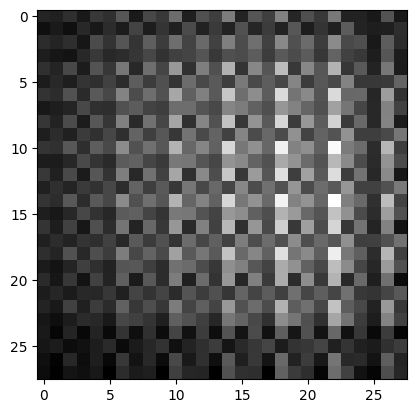

In [ ]:
idx = np.random.randint(10)

img = (new_images[idx] + 1) * 127.5
img = img.reshape(28, 28)

plt.imshow(img, cmap='gray')
plt.show()